# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## ¿Qué es DBSCAN?

DBSCAN es un algoritmo de clustering basado en **densidad**. A diferencia de K-means:
- No requiere especificar el número de clusters de antemano
- Puede encontrar clusters de formas arbitrarias
- Detecta automáticamente **outliers** (puntos de ruido, etiquetados como -1)

## Hiperparámetros clave:
- **eps**: Radio máximo de la vecindad alrededor de un punto
- **min_samples**: Número mínimo de puntos en una vecindad para considerar un punto como *core*


## Paso 1: Importar librerías y generar datos

Usaremos `make_moons` porque crea datos con forma no convexa (ideal para ver la ventaja de DBSCAN sobre K-means).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

%matplotlib inline


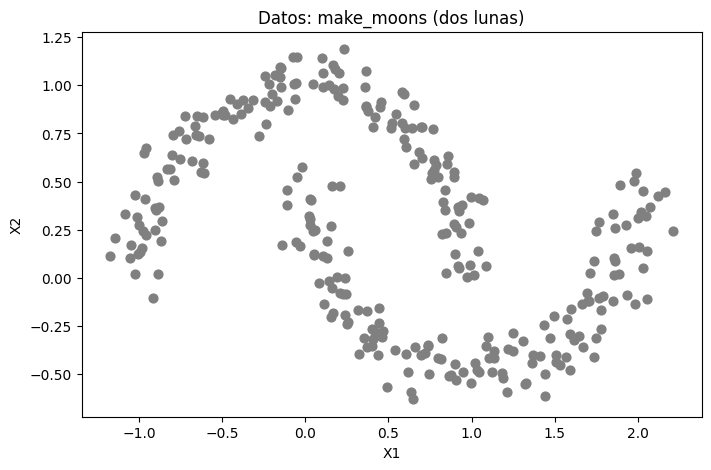

In [2]:
X, y_true = make_moons(n_samples=300, noise=0.08, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=40, c='gray')
plt.title('Datos: make_moons (dos lunas)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


## Paso 2: Escalar los datos y aplicar DBSCAN

DBSCAN es sensible a la escala de los datos, por lo que **siempre** debemos estandarizar.


In [3]:
X_scaled = StandardScaler().fit_transform(X)

dbscan = DBSCAN(eps=0.35, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

print('Etiquetas únicas:', np.unique(labels))
print('Número de clusters:', len(set(labels)) - (1 if -1 in labels else 0))
print('Puntos de ruido (outliers):', list(labels).count(-1))


Etiquetas únicas: [0 1]
Número de clusters: 2
Puntos de ruido (outliers): 0


## Paso 3: Visualizar los clusters


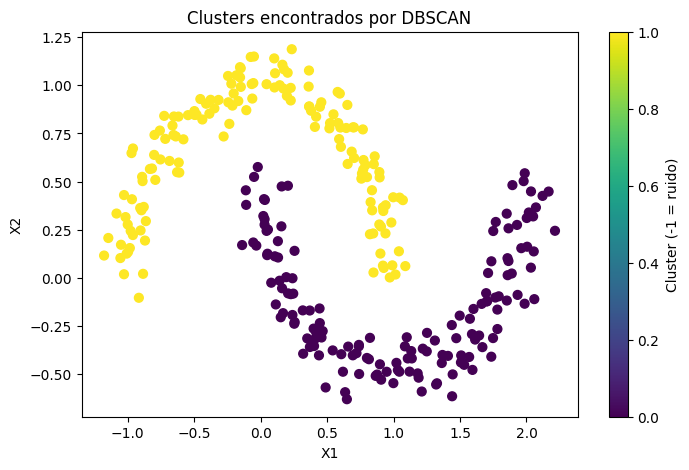

In [4]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40)
plt.colorbar(scatter, label='Cluster (-1 = ruido)')
plt.title('Clusters encontrados por DBSCAN')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


## Paso 4: Ajustar eps y min_samples

Los resultados dependen mucho de `eps`. Probemos varios valores.


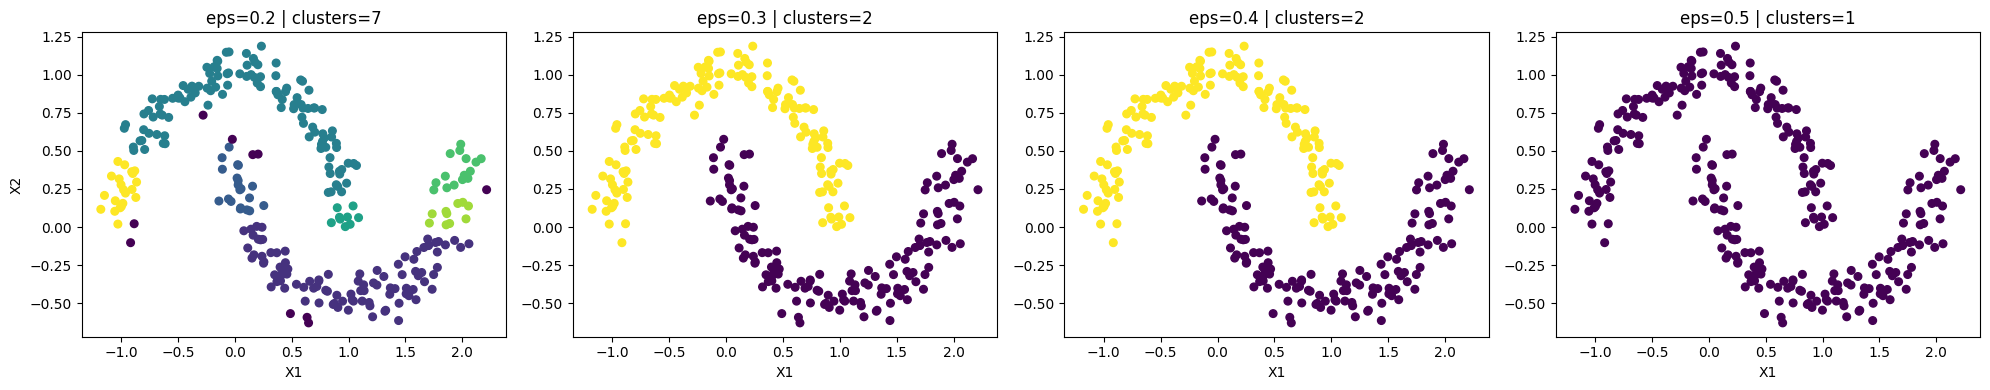

In [5]:
eps_values = [0.2, 0.3, 0.4, 0.5]
min_samples_val = 5

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=min_samples_val)
    lbls = db.fit_predict(X_scaled)
    n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
    axes[i].scatter(X[:, 0], X[:, 1], c=lbls, cmap='viridis', s=30)
    axes[i].set_title(f'eps={eps} | clusters={n_clusters}')
    axes[i].set_xlabel('X1')
axes[0].set_ylabel('X2')
plt.tight_layout()
plt.show()


## Paso 5: Método del k-distance para elegir eps

Una técnica común es graficar las distancias al k-ésimo vecino más cercano (k = min_samples) y buscar el "codo".


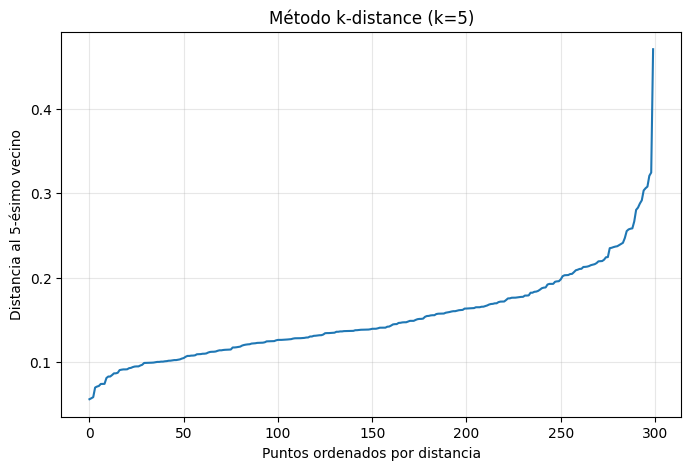

Sugerencia: el eps recomendado está en el codo de la curva (aprox. 0.3-0.4).


In [6]:
from sklearn.neighbors import NearestNeighbors

k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title(f'Método k-distance (k={k})')
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al {k}-ésimo vecino')
plt.grid(True, alpha=0.3)
plt.show()

print('Sugerencia: el eps recomendado está en el codo de la curva (aprox. 0.3-0.4).')


## Paso 6: Comparación con K-means

Veamos por qué DBSCAN es mejor para datos con formas no convexas.


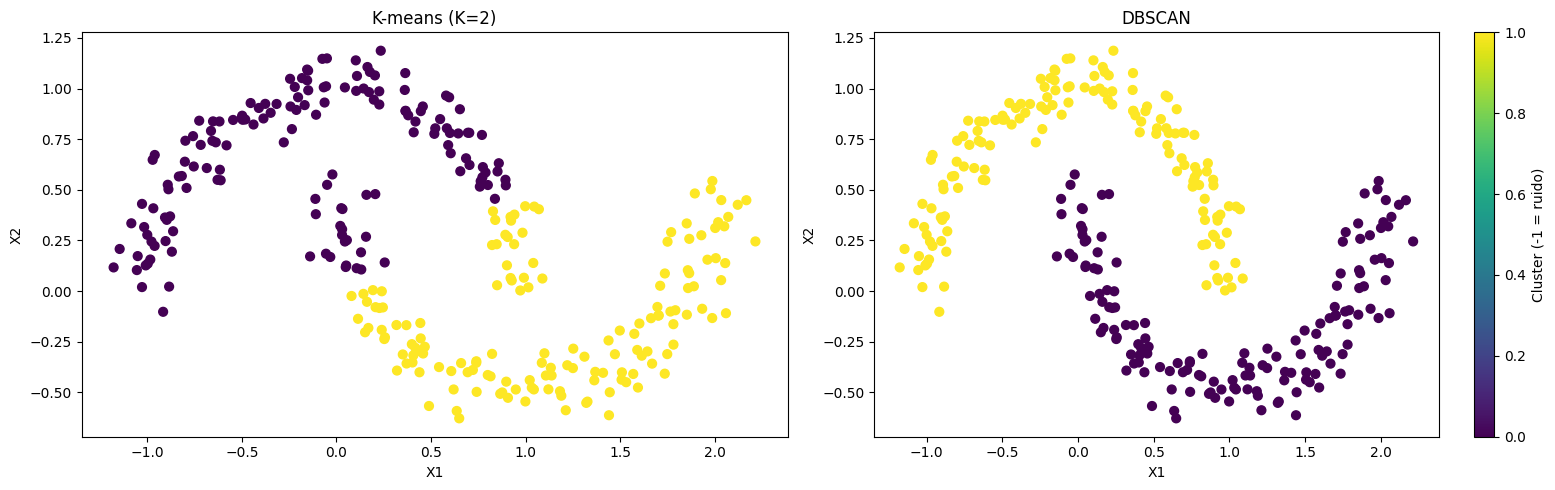

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', s=40)
ax1.set_title('K-means (K=2)')
ax1.set_xlabel('X1'); ax1.set_ylabel('X2')

sc = ax2.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40)
plt.colorbar(sc, ax=ax2, label='Cluster (-1 = ruido)')
ax2.set_title('DBSCAN')
ax2.set_xlabel('X1'); ax2.set_ylabel('X2')

plt.tight_layout()
plt.show()


## Resumen de DBSCAN

| Ventaja | Desventaja |
|---|---|
No necesita K | Sensible a escala |
Detecta ruido/outliers | Resultados dependen de eps/min_samples |
Formas arbitrarias | Lento en datos muy grandes |
